# DINOv2/v3 CPU 测试 - 特征可视化

这是一个 DINO 特征可视化示例，专为 CPU 环境优化。

**关于模型访问：**
- **DINOv2**: 公开可用，无需申请（本 notebook 使用）
- **DINOv3**: 需要申请权限 → [申请地址](https://ai.meta.com/resources/models-and-libraries/dinov3-downloads/)

**适用环境：**
- AMD Ryzen CPU (无 CUDA)
- 32GB 内存
- 使用 ViT-S/Small 小型模型

**功能：**
1. 加载 DINO 模型 (CPU 版)
2. 提取图像特征
3. PCA 降维可视化

## 1. 环境配置

In [15]:
import os
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torchvision.transforms.functional as TF
from sklearn.decomposition import PCA

# 设置设备
DEVICE = 'cpu'
print(f"PyTorch 版本: {torch.__version__}")
print(f"使用设备: {DEVICE}")

PyTorch 版本: 2.10.0+cpu
使用设备: cpu


## 2. 加载 DINOv3 模型

我们使用 ViT-S/16 模型，这是最小的模型，最适合 CPU 推理。

| 模型 | 参数量 | 特征维度 | CPU 速度 |
|------|--------|---------|----------|
| ViT-S/16 | 21M | 384 | ~0.5s |
| ViT-B/16 | 86M | 768 | ~1.5s |
| ViT-L/16 | 300M | 1024 | ~3s |

In [16]:
# DINOv3 本地仓库路径
REPO_DIR = r'd:\AI\Git\dinov3.git'

# 可选模型列表
AVAILABLE_MODELS = {
    'dinov3_vits16': {'layers': 12, 'dim': 384, 'params': '21M'},
    'dinov3_vits16plus': {'layers': 12, 'dim': 384, 'params': '29M'},
    'dinov3_vitb16': {'layers': 12, 'dim': 768, 'params': '86M'},
}

# 选择小模型，适合 CPU
MODEL_NAME = 'dinov3_vits16'

print(f"正在加载模型: {MODEL_NAME}")
print(f"参数量: {AVAILABLE_MODELS[MODEL_NAME]['params']}")
print(f"特征维度: {AVAILABLE_MODELS[MODEL_NAME]['dim']}")
print("请耐心等待，首次加载需要下载权重...")

正在加载模型: dinov3_vits16
参数量: 21M
特征维度: 384
请耐心等待，首次加载需要下载权重...


In [19]:
# ============================================================
# 方式 1: 使用 Hugging Face DINOv2 (公开可用，无需申请)
# ============================================================
from transformers import AutoModel, AutoImageProcessor

# # DINOv2 与 DINOv3 架构类似，可用于学习
# HF_MODEL = 'facebook/dinov2-small'  # 公开可用

# print(f"正在从 Hugging Face 加载: {HF_MODEL}")
# print("(首次下载约 80MB，请耐心等待)")

# processor = AutoImageProcessor.from_pretrained(HF_MODEL)
# model = AutoModel.from_pretrained(HF_MODEL)
# model.eval()

# # 统计参数
# total_params = sum(p.numel() for p in model.parameters())
# print(f"\n✓ 模型加载完成!")
# print(f"  参数量: {total_params / 1e6:.1f}M")

# ============================================================
# 方式 2: 使用 DINOv3 (需要申请权限)
# ============================================================
# 取消注释以下代码并填入本地权重路径:
#
REPO_DIR = r'd:\AI\Git\dinov3.git'
WEIGHTS_PATH = 'dinov3_vits16_pretrain_lvd1689m-08c60483.pth'  # 申请后获得的权重

model = torch.hub.load(
    repo_or_dir=REPO_DIR,
    model='dinov3_vits16',
    source='local',
    weights=WEIGHTS_PATH
)

print(model)

DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (rope_embed): RopePositionEmbedding()
  (blocks): ModuleList(
    (0-11): 12 x SelfAttentionBlock(
      (norm1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (attn): SelfAttention(
        (qkv): LinearKMaskedBias(in_features=384, out_features=1152, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (norm2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
      (ls2): LayerScale()
    )
  )
  (norm): LayerN

## 3. 加载测试图像

原始图像尺寸: (1134, 2016)
处理后尺寸: torch.Size([3, 224, 224])


D:\Env\Python\3.11.4\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Env\Python\3.11.4\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Env\Python\3.11.4\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Env\Python\3.11.4\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


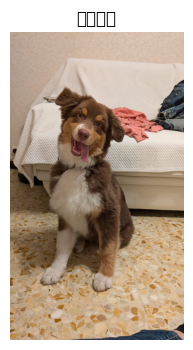

In [20]:
# 图像预处理参数
PATCH_SIZE = 16
IMAGE_SIZE = 224  # 使用较小的尺寸加快 CPU 推理
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

def load_image_from_url(url: str) -> Image.Image:
    """从 URL 加载图片"""
    with urllib.request.urlopen(url) as f:
        return Image.open(f).convert("RGB")

def load_image_from_path(path: str) -> Image.Image:
    """从本地路径加载图片"""
    return Image.open(path).convert("RGB")

def preprocess_image(image: Image.Image, image_size: int = IMAGE_SIZE) -> tuple:
    """预处理图像"""
    image_resized = TF.resize(image, (image_size, image_size))
    image_tensor = TF.to_tensor(image_resized)
    image_normalized = TF.normalize(image_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD)
    return image_normalized, image_resized

# 加载测试图片
image_url = "https://dl.fbaipublicfiles.com/dinov3/notebooks/pca/test_image.jpg"
image = load_image_from_url(image_url)

# 预处理
image_tensor, image_resized = preprocess_image(image)

print(f"原始图像尺寸: {image.size}")
print(f"处理后尺寸: {image_tensor.shape}")

# 显示原图
plt.figure(figsize=(6, 4))
plt.imshow(image)
plt.axis('off')
plt.title("原始图像")
plt.show()

## 4. 提取特征

In [ ]:
# 特征维度
feature_dim = 384  # ViT-S/Small 特征维度

print(f"提取特征中... (在 CPU 上可能需要几秒钟)")

# DINOv3 需要使用 forward_features 获取完整特征
with torch.inference_mode():
    # forward_features 返回字典，包含 patch 特征
    outputs = model.forward_features(image_tensor.unsqueeze(0))
    
    # 获取 patch tokens: [batch, num_patches, dim]
    patch_features = outputs["x_norm_patchtokens"]
    
    # 重塑为空间维度 [batch, h, w, dim] -> [dim, h, w]
    h_patches = w_patches = IMAGE_SIZE // PATCH_SIZE
    features = patch_features.reshape(1, h_patches, w_patches, feature_dim)
    features = features.permute(0, 3, 1, 2).squeeze(0)  # [dim, h, w]

print(f"特征形状: {features.shape}")
print(f"Patch 数量: {h_patches} x {w_patches} = {h_patches * w_patches}")

## 5. PCA 可视化

In [ ]:
# 准备特征矩阵
h_patches = features.shape[1]
w_patches = features.shape[2]

# 展平为 [num_patches, dim]
features_flat = features.view(feature_dim, -1).permute(1, 0).numpy()
print(f"展平后特征: {features_flat.shape}")

# PCA 降维
pca = PCA(n_components=3, whiten=True)
features_pca = pca.fit_transform(features_flat)
print(f"PCA 后特征: {features_pca.shape}")
print(f"解释方差比: {pca.explained_variance_ratio_}")
print(f"总解释方差: {sum(pca.explained_variance_ratio_):.2%}")

In [ ]:
# 可视化
pca_image = features_pca.reshape(h_patches, w_patches, 3)

# 归一化并增强对比度
pca_tensor = torch.from_numpy(pca_image).float()
pca_normalized = torch.nn.functional.sigmoid(pca_tensor.mul(2.0))

# 绘图
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image_resized)
axes[0].set_title('原始图像')
axes[0].axis('off')

axes[1].imshow(pca_normalized.numpy())
axes[1].set_title(f'PCA 特征可视化\n({h_patches}x{w_patches} patches)')
axes[1].axis('off')

axes[2].imshow(pca_image[:, :, 0], cmap='viridis')
axes[2].set_title('第一主成分')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 6. 测试你自己的图片

In [ ]:
def extract_and_visualize(image_source: str, is_url: bool = True):
    """完整的特征提取和可视化流程"""
    
    # 加载图片
    if is_url:
        img = load_image_from_url(image_source)
    else:
        img = load_image_from_path(image_source)
    
    # 预处理
    img_tensor, img_resized = preprocess_image(img)
    
    # 提取特征 (DINOv3 原生模型)
    with torch.inference_mode():
        outputs = model.forward_features(img_tensor.unsqueeze(0))
        patch_features = outputs["x_norm_patchtokens"]
        h_p = w_p = IMAGE_SIZE // PATCH_SIZE
        features = patch_features.reshape(1, h_p, w_p, feature_dim).permute(0, 3, 1, 2).squeeze(0)
    
    # PCA
    features_flat = features.view(feature_dim, -1).permute(1, 0).numpy()
    pca = PCA(n_components=3, whiten=True)
    pca_result = pca.fit_transform(features_flat)
    
    # 可视化
    pca_img = pca_result.reshape(h_p, w_p, 3)
    pca_norm = torch.nn.functional.sigmoid(torch.from_numpy(pca_img).float().mul(2.0))
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img_resized)
    axes[0].set_title('原始图像')
    axes[0].axis('off')
    axes[1].imshow(pca_norm.numpy())
    axes[1].set_title('DINO 特征 PCA')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

# 测试更多图片
test_images = [
    "http://images.cocodataset.org/val2017/000000039769.jpg",  # 猫
]

for img_url in test_images:
    print(f"\n处理图片: {img_url}")
    try:
        extract_and_visualize(img_url, is_url=True)
    except Exception as e:
        print(f"处理失败: {e}")

## 总结

恭喜！你已经成功在 CPU 上运行了 DINOv3！

**下一步学习：**
1. 尝试不同的图片
2. 比较不同模型 (ViT-B vs ViT-S)
3. 学习 `foreground_segmentation.ipynb` - 前景分割
4. 学习 `dense_sparse_matching.ipynb` - 图像匹配